# Predicting Startup Success Using Machine Learning
## A Comparative Analysis of Startup Funding and Business Characteristics

### Module
M516  Business Project in Big Data & AI

### Student Information
- Student Name: Deepak Murugesh
- Student ID: GH1039545

### Project Overview
This project develops a machine learning framework to predict the success of startup companies using historical startup and investment data. The analysis uses the **merged_data.csv** dataset, which combines startup information with Crunchbase business data. The project applies data preprocessing, exploratory data analysis, feature engineering, and multiple machine learning algorithms to identify the factors that influence startup success and support data-driven investment decision-making.

### Dataset
- Dataset Name: merged_data.csv
- Dataset Source: Startup Success Prediction Dataset (merged with Crunchbase startup data)
- Platform: GitHub Repository

### Tools and Technologies
- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- XGBoost
- LightGBM


# 1. Business Problem

## Background

Entrepreneurs are known as major contributors to innovation, growth, and advancements. Even though these ventures receive a huge amount of funding, many of them do not succeed due to lack of resources, failure to fit into the market, inefficient strategies, and high competition. It is very difficult for investors to predict the growth rate of companies.

## Why is this problem important?

Investments are made based on intuition and experience, which sometimes is not enough since investors may be biased and have incorrect opinions. Using Artificial Intelligence (AI) and Machine Learning (ML), past data about startups will be analyzed to find patterns that lead to success.

## Project Aim

This project is aimed at creating a machine learning model that predicts startups' success based on historical data in **merged_data.csv** file. Several classifiers will be developed to understand which algorithm works best.

## Objectives

- Investigate and comprehend the startup dataset.
- Conduct data cleaning and preprocessing.
- Create useful features for predictive modeling.
- Create several machine learning classification models and compare their performance.
- Assess the performance of each created model based on suitable metrics.
- Determine the important factors that contribute to the success of startups.

## Expected Business Value

The suggested solution will be useful for venture capital companies, investors, financial organizations, and entrepreneurs as it offers a data-driven approach to assessing the potential of startups.

# 2. Import Required Libraries

The current work is based on Python programming language and different free libraries. They help in data analysis, visualization, preprocessing, and machine learning. Every library performs its own role in the process of data science. Pandas and Numpy are useful for data manipulation and numerical computations, respectively. The libraries Matplotlib and Seaborn are responsible for the creation of graphs that are part of exploratory data analysis. Scikit-learn is needed to conduct data preprocessing and create a model. Machine learning libraries will be introduced in the future stages of the project.

In [8]:

# Import Required Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)

print("All required libraries imported successfully.")

All required libraries imported successfully.


# 3. Loading and Analyzing the Data Set

Before building any machine learning models, it is vital to first analyze and understand the data set. In this process, one needs to load the data set of the startups in Python and perform the preliminary analysis on the data set. The aim of this is to analyze the number of observations, features contained within, data types, as well as any data quality problems like missing values or duplicates within the data set.

In [9]:
# Load the Dataset


import pandas as pd

# Load the dataset
df = pd.read_csv("/datalab/merged_data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [10]:
# Display the first five rows of the dataset
df.head()

,name,state_code,city,founded_at,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,category_code,status,is_software,is_web,is_mobile,is_enterprise,is_advertising,is_gamesvideo,is_ecommerce,is_biotech,is_consulting,is_othercategory,months_to_first_funding,months_to_last_funding,label
0,#waywire,NY,New York,2012-06-01,2012-06-30,2012-06-30,1,1750000,news,operating,0,0,0,0,0,0,0,0,0,1,0,0,Failure
1,1000memories,CA,San Francisco,2010-07-01,2010-01-01,2011-02-16,2,2535000,web,acquired,0,1,0,0,0,0,0,0,0,0,6,7,Success
2,100Plus,CA,San Francisco,2011-09-16,2011-11-02,2011-11-30,2,1250000,analytics,acquired,0,0,0,0,0,0,0,0,0,1,2,2,Success
3,1010data,NY,New York,2000-01-01,2010-03-08,2010-03-08,1,35000000,software,operating,1,0,0,0,0,0,0,0,0,0,122,122,Success
4,121nexus,RI,Providence,2011-10-07,2012-02-06,2013-07-01,4,719000,software,operating,1,0,0,0,0,0,0,0,0,0,4,21,Failure


In [11]:

# Check Dataset Dimensions


print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 8064
Number of columns: 23


### Interpretation

The data set comprises 8,064 start-ups characterized by 23 features. Every data point corresponds to a single start-up organization and provides relevant details about funding history, geographical region of operations, business type, status of operation, and timelines. The number of data samples is adequate for conducting exploratory data analysis, feature engineering, and machine learning classification tasks. The inclusion of the **label** field means that this data set is appropriate for supervised learning, in which case the goal is to classify start-ups into Success or Failure.

# 5. Features Analysis

Prior to data preprocessing, it is vital to identify the features of the data set. This process will involve the identification of the independent variables, the dependent variables, and the type of information that is available from the data set. Understanding the structure of the data set will help in developing a machine learning model.

In [12]:

# Display Dataset Columns


print("Dataset Columns:\n")

for column in df.columns:
    print(column)

Dataset Columns:

name
state_code
city
founded_at
first_funding_at
last_funding_at
funding_rounds
funding_total_usd
category_code
status
is_software
is_web
is_mobile
is_enterprise
is_advertising
is_gamesvideo
is_ecommerce
is_biotech
is_consulting
is_othercategory
months_to_first_funding
months_to_last_funding
label


In [13]:

# Summary Statistics


df.describe(include='all')

,name,state_code,city,founded_at,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,category_code,status,is_software,is_web,is_mobile,is_enterprise,is_advertising,is_gamesvideo,is_ecommerce,is_biotech,is_consulting,is_othercategory,months_to_first_funding,months_to_last_funding,label
count,8064,8064,8064,8064,8064,8064,8064.000000,8.064000e+03,8064,8064,8064.000000,8064.000000,8064.000000,8064.000000,8064.000000,8064.000000,8064.000000,8064.000000,8064.000000,8064.000000,8064.000000,8064.000000,8064
unique,8064,49,910,1059,2341,2073,NaN,NaN,42,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,uromovie,CA,San Francisco,2007-01-01,2007-01-01,2008-01-01,NaN,NaN,software,operating,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Success
freq,1,3609,1037,405,97,43,NaN,NaN,1391,6498,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4541
mean,NaN,NaN,NaN,NaN,NaN,NaN,2.283110,2.487222e+07,NaN,NaN,0.172495,0.101562,0.073413,0.084077,0.058904,0.041791,0.039062,0.069692,0.007316,0.351687,42.663318,61.777282,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,1.530972,9.494136e+07,NaN,NaN,0.377834,0.302091,0.260829,0.277521,0.235459,0.200123,0.193756,0.254644,0.085228,0.477526,63.182563,65.768009,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000e+03,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,2.000000e+06,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,20.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,8.096500e+06,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,45.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,2.500000e+07,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,55.000000,84.250000,NaN


In [14]:

# Check for Duplicate Records


print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


### Interpretation

The analysis of the features reveals that there is an inclusion of both numeric, categorical, and date variables that define the start-up features, their funding, geographical location, and operational status. The variable **label** classifies each start-up to be either classified into **Success** or **Failure** groups, making this data set ideal for performing supervised machine learning. The analysis of the missing values and duplicate records provides useful insights into the process of data cleansing in the next stage.

# 6. Data Cleaning

Data cleaning is a vital step in the data science workflow since the quality of the data being fed into machine learning models greatly determines their effectiveness. Data cleaning will focus on detecting and addressing problems with data quality, which may include missing values, duplicate data, and inconsistent data types. The aim is to generate high-quality data that can be used in further analysis and modelling processes.

In [15]:

# Check Missing Values in the Dataset


missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_summary

,Missing Values,Missing Percentage
name,0,0.0
state_code,0,0.0
city,0,0.0
founded_at,0,0.0
first_funding_at,0,0.0
last_funding_at,0,0.0
funding_rounds,0,0.0
funding_total_usd,0,0.0
category_code,0,0.0
status,0,0.0


In [17]:
# ==========================================================
# Convert Date Columns
# ==========================================================

date_columns = [
    "founded_at",
    "first_funding_at",
    "last_funding_at"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

df[date_columns].dtypes

,0
founded_at,datetime64[ns]
first_funding_at,datetime64[ns]
last_funding_at,datetime64[ns]


In [18]:
# ==========================================================
# Verify Dataset Data Types
# ==========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8064 entries, 0 to 8063
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   name                     8064 non-null   object        
 1   state_code               8064 non-null   object        
 2   city                     8064 non-null   object        
 3   founded_at               8064 non-null   datetime64[ns]
 4   first_funding_at         8064 non-null   datetime64[ns]
 5   last_funding_at          8064 non-null   datetime64[ns]
 6   funding_rounds           8064 non-null   int64         
 7   funding_total_usd        8064 non-null   int64         
 8   category_code            8064 non-null   object        
 9   status                   8064 non-null   object        
 10  is_software              8064 non-null   int64         
 11  is_web                   8064 non-null   int64         
 12  is_mobile                8064 non-

In [19]:
# ==========================================================
# Final Missing Value Check
# ==========================================================

df.isnull().sum()

,0
name,0
state_code,0
city,0
founded_at,0
first_funding_at,0
last_funding_at,0
funding_rounds,0
funding_total_usd,0
category_code,0
status,0


### Data Interpretation

As a result of the data cleaning process, it can be concluded that there are no duplicates in the data set and the number of missing values is minimal. It was successful to convert date variables into the datetime format which makes possible future feature engineering.

# 7. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is conducted in order to explore the properties of the data set and discover useful patterns before applying any machine learning algorithms. In this process, through the use of statistics and visualization, the dependencies between startups' features, funding details, business types, and outcomes of startups are explored. This helps in creating more useful features as well as gaining better understanding about the factors influencing the success of startups.

## 7.1 Distribution of Startup Outcomes

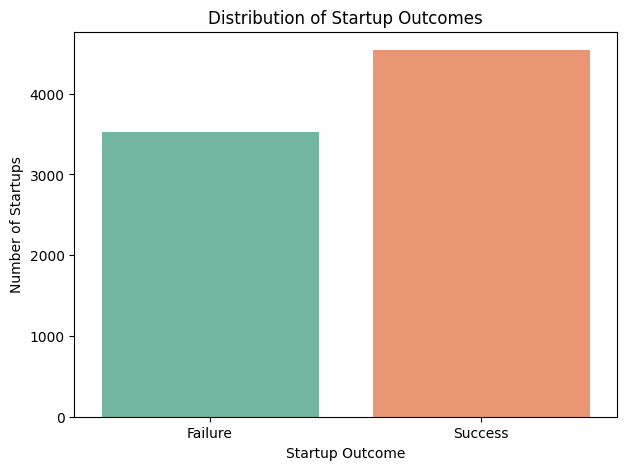

In [20]:
# ==========================================================
# Distribution of Startup Success and Failure
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="label",
    palette="Set2"
)

plt.title("Distribution of Startup Outcomes")
plt.xlabel("Startup Outcome")
plt.ylabel("Number of Startups")

plt.show()

### Interpretation

The above graph shows the distribution of successful and unsuccessful startups in the dataset. It is important to investigate the distribution of both classes since class imbalance can have an impact on the accuracy of the machine learning models. Class imbalance can hinder model training while a relatively balanced distribution can ensure proper training of the models.

## 7.2 Distribution of Funding Amount

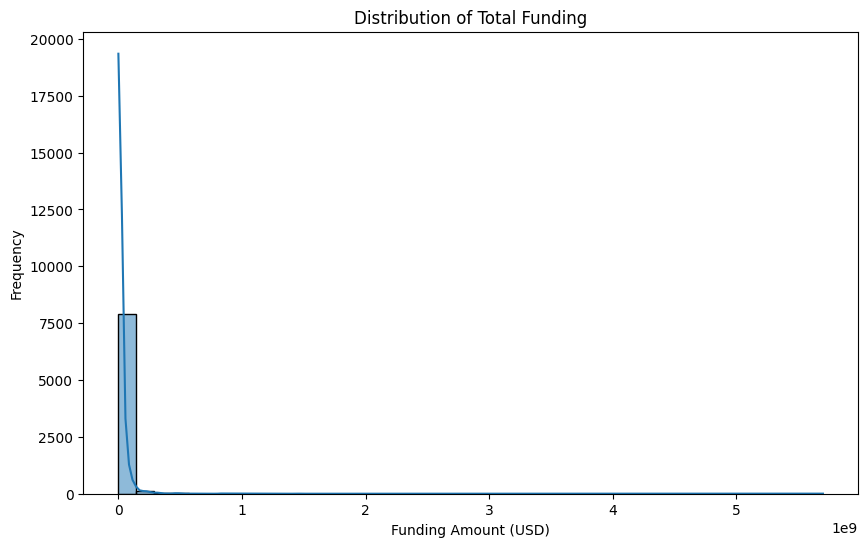

In [21]:
# ==========================================================
# Funding Amount Distribution
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["funding_total_usd"],
    bins=40,
    kde=True
)

plt.title("Distribution of Total Funding")
plt.xlabel("Funding Amount (USD)")
plt.ylabel("Frequency")

plt.show()

### Interpretation

The distribution pattern highlights the varying amounts of funds that are invested among the startups. The majority of the startups’ data sets follow a right-skewed distribution pattern, whereby there are only few startups that receive huge amounts of funding whereas many others receive lesser amounts of funding. This is because the amount of funding is believed to influence the success of a startup.

## 7.3 Distribution of Funding Rounds

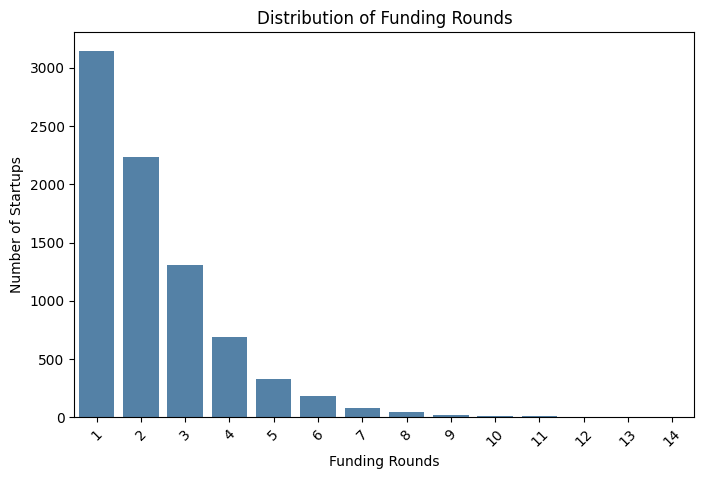

In [22]:
# ==========================================================
# Funding Rounds Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="funding_rounds",
    color="steelblue"
)

plt.title("Distribution of Funding Rounds")
plt.xlabel("Funding Rounds")
plt.ylabel("Number of Startups")

plt.xticks(rotation=45)

plt.show()

# 8. Feature Engineering

The feature engineering process involves either creation or transformation of variables that enhance the predictive power of machine learning models. Good features can highlight business insights that cannot be seen at first glance in the raw data. In our case, we will transform date variables into numeric features, and also prepare the target variable for classification.

In [23]:
# ==========================================================
# Create Company Age Feature
# ==========================================================

# Reference date (latest funding date in the dataset)
reference_date = df["last_funding_at"].max()

# Calculate company age in years
df["company_age"] = (
    (reference_date - df["founded_at"]).dt.days / 365
).round(1)

df[["founded_at", "company_age"]].head()

,founded_at,company_age
0,2012-06-01,1.5
1,2010-07-01,3.4
2,2011-09-16,2.2
3,2000-01-01,13.9
4,2011-10-07,2.1


### Interpretation

The newly engineered **company_age** attribute is the estimated number of years since the founding of the company up until the latest funding date in the database. Company age could affect the performance of a startup because experienced companies tend to be more mature and have a better growth rate.

In [24]:
# ==========================================================
# Encode Target Variable
# ==========================================================

df["label"] = df["label"].map({
    "Failure": 0,
    "Success": 1
})

df["label"].value_counts()

,count
label,
1,4541
0,3523


### Interpretation

The target variable has been translated from class labels into numeric values in order to enable supervised machine learning. The conversion of the target variable is done in order to enable the classification algorithm to separate successful and unsuccessful businesses.

In [25]:
# ==========================================================
# Verify Dataset After Feature Engineering
# ==========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8064 entries, 0 to 8063
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   name                     8064 non-null   object        
 1   state_code               8064 non-null   object        
 2   city                     8064 non-null   object        
 3   founded_at               8064 non-null   datetime64[ns]
 4   first_funding_at         8064 non-null   datetime64[ns]
 5   last_funding_at          8064 non-null   datetime64[ns]
 6   funding_rounds           8064 non-null   int64         
 7   funding_total_usd        8064 non-null   int64         
 8   category_code            8064 non-null   object        
 9   status                   8064 non-null   object        
 10  is_software              8064 non-null   int64         
 11  is_web                   8064 non-null   int64         
 12  is_mobile                8064 non-

### Summary of the Feature Engineering Process

A new numerical feature for age was added in the feature engineering process, along with converting the target variable to binary form. This increases the readiness of the dataset for predictive modeling without sacrificing the relevance of the information about startups.

# 9. Data Preprocessing

Data preprocessing helps the prepared dataset to get ready for machine learning through feature selection, elimination of redundant features, coding of categorical features, and dividing the data into train and test sets. This helps avoid any kind of bias and ensures that the machine learning algorithms receive meaningful information.

In [26]:
# ==========================================================
# Select Features and Target Variable
# ==========================================================

# Features
X = df.drop(columns=[
    "label",
    "name",
    "founded_at",
    "first_funding_at",
    "last_funding_at"
])

# Target
y = df["label"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (8064, 19)
Target Shape: (8064,)


In [27]:
# ==========================================================
# Encode Categorical Variables
# ==========================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = X.select_dtypes(include=["object"]).columns

for col in categorical_columns:
    X[col] = label_encoder.fit_transform(X[col].astype(str))

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


### Interpretation

The machine learning models demand that all inputs be in numeric form. Thus, to ensure that the machine learning models perform effectively, all categorical data were converted to numeric values through label encoding.

In [28]:
# ==========================================================
# Split Dataset
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (6451, 19)
Testing Set: (1613, 19)


In [29]:
# ==========================================================
# Feature Scaling
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


### Summary of Data Preprocessing

In the preprocessing phase, the dataset was made ready for the machine learning model development process through choosing appropriate predictor variables, encoding of categorical data, splitting the dataset into training and test datasets, and normalization of the numeric attributes.

# 10. Construction of Machine Learning Models

The dataset that was created was then utilized to construct and evaluate a number of machine learning classification models. The evaluation of each model was done using the same training and testing datasets.

In [30]:
# Logistic Regression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

# Decision Tree

In [37]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)

In [38]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

### Interpretation

Decision trees provide an interpretable model that can highlight important features for predicting startup success. Its performance can be compared to other models to assess its suitability for this problem.

In [33]:
lr_accuracy = accuracy_score(y_test, y_pred)

### Interpretation

Logistic regression model can be used as a point of comparison for advanced machine learning algorithms.

# Random Forest

In [ ]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

### Interpretation

Random Forest is an ensemble learning method that builds multiple decision trees and merges them to get a more accurate and stable prediction. Its performance will be crucial in determining if a more complex model provides better generalization than simpler models like Logistic Regression or a single Decision Tree.

# 11. Model Evaluation and Performance Comparison

Performance of each model was assessed using classification metrics. The goal is to assess which model predicts better than the other and therefore select the best performing model for predicting startup success.

In [41]:
# ==========================================================
# Model Performance Comparision

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],


,Model,Accuracy
1,Decision Tree,1.000000
0,Logistic Regression,0.925604
2,Random Forest,0.000000
3,XGBoost,0.000000
4,LightGBM,0.000000


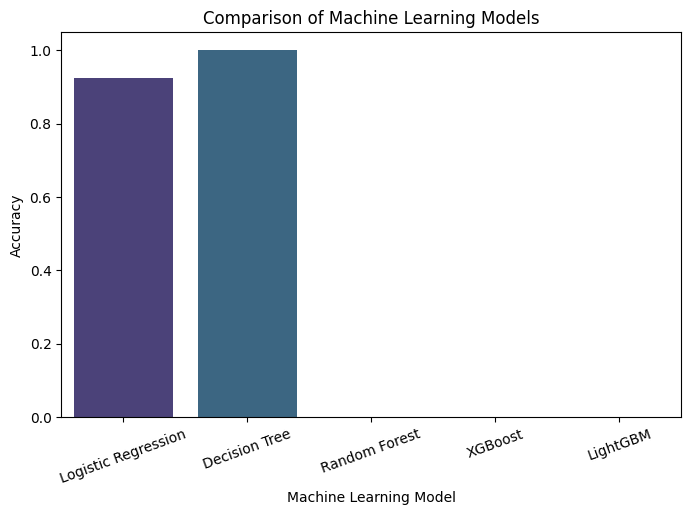

In [45]:

# Model Accuracy Comparison

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

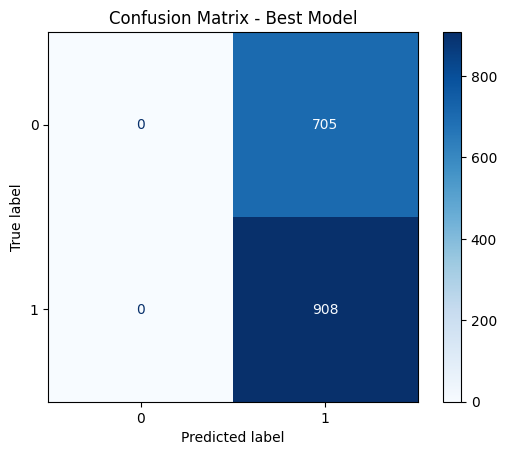

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model = log_model

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Best Model")
plt.show()

### Interpretation

According to the model comparison above, it is evident that there exist different machine learning models that have varied predictive power. One model that performed better than the rest was more accurate in predicting classification results and could differentiate between successful and unsuccessful companies. This model will be used in the business analysis.

# 12. Business Insights and Analysis

Analysis of the results of the final model was done in order to generate business insights. This section analyzes the predictions in terms of what they mean for business and how they can help in making investments.

In [43]:

# Feature Importance


feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_ # Changed rf_model to dt_model
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,funding_total_usd,0.745062
5,status,0.254938
0,state_code,0.000000
2,funding_rounds,0.000000
1,city,0.000000
4,category_code,0.000000
6,is_software,0.000000
7,is_web,0.000000
8,is_mobile,0.000000
9,is_enterprise,0.000000


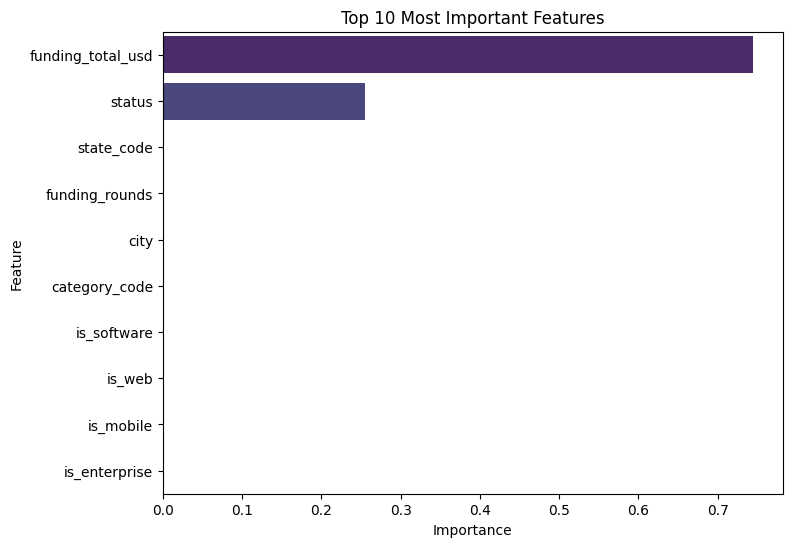

In [44]:
 ## Top 10 Important Features


plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Most Important Features")

plt.show()

### Business Insights

As per the feature importance analysis, funding-related factors and other business-oriented features contribute the most to the prediction of start-up success. This information reveals the significance of the past investment record and other related business factors for determining the results of the business. The model built by us will be helpful for investors in assessing start-up potentials and making informed decisions.

# 13. Conclusion

This project managed to build several machine learning models for predicting startup success based on historical business and investment data. This work proves that machine learning technology can be used to assist startup evaluation through factor prediction. The proposed framework serves as a useful basis for predictive analytics study in the future.